<h1>Intro to Monte Carlo Simulations</h1>
In this script, we are introducing how to code a Monte Carlo simulation on a stock portfolio


In [210]:
import math

#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

<h3>We use Yahoo Finance package to import data about our stocks</h3>
<ul>
<li> StockData: pandas dataframe that contains 'Close', 'High', 'Low', 'Volume'
<li> .pct_change(): finds the fractional change at one time step compared to the previous time step
<li> .mean(): will find the mean returns of the fractional changes. ie, we figure out on average, how much does the stock change per day over <b>our observed time</b>
<li> Covariance Matrix: how correlated two stocks are (i,j) index by comparing each stock to its mean fractional return and if two stocks are above their mean returns at the same time. The diagonal is <it>not</it> 1, it is a measure of the variance (volatility) of the stock
</ul>
<u>Key Insight:</u> Our meanReturns and covMatrix are a function of lookback period since they both consider the mean of the sample data. As we increase the look-back period, our projections will most likely get larger


In [211]:
#import data
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start, end, auto_adjust=False)
  stockData = stockData['Close']
  returns = stockData.pct_change().dropna()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

stockList = ['AMZN', 'CEG', 'NFLX', 'QQQI', 'SPYG', 'VXUS', 'VTI']
time = "Now" #options, Jan, Now
T = 365 #timeframe in days
look_back = 365

match time:
    case "Jan":
        endDate = "2026-01-29"
        endDate = dt.datetime.strptime(endDate, "%Y-%m-%d").date()
    case "Now":
        endDate = dt.datetime.now()

startDate = endDate - dt.timedelta(days = look_back)

meanReturns, covMatrix = get_data(stockList, startDate, endDate)
print(meanReturns)
print()
print(covMatrix)

[*********************100%***********************]  7 of 7 completed

Ticker
AMZN    0.000729
CEG     0.002358
NFLX    0.001124
QQQI    0.000090
SPYG    0.000783
VTI     0.000586
VXUS    0.000596
dtype: float64

Ticker      AMZN       CEG      NFLX      QQQI      SPYG       VTI      VXUS
Ticker                                                                      
AMZN    0.000397  0.000232  0.000155  0.000157  0.000187  0.000144  0.000083
CEG     0.000232  0.001348  0.000184  0.000203  0.000248  0.000178  0.000115
NFLX    0.000155  0.000184  0.000417  0.000109  0.000128  0.000091  0.000057
QQQI    0.000157  0.000203  0.000109  0.000126  0.000137  0.000107  0.000074
SPYG    0.000187  0.000248  0.000128  0.000137  0.000167  0.000126  0.000083
VTI     0.000144  0.000178  0.000091  0.000107  0.000126  0.000106  0.000074
VXUS    0.000083  0.000115  0.000057  0.000074  0.000083  0.000074  0.000089


<h3>This is where we set the Weights of the Portfolio</h3>
ie. what percent of our portfolio goes into each stock

In [212]:
#stockList = ['AMZN', 'CEG', 'NFLX', 'QQQI', 'SPYG', 'VXUS', 'VTI']
weights = np.array([5.87, 8.56, 5.09, 11.96, 15.28, 21.4, 31.63])
weights = weights / 100
weights /= np.sum(weights)

<h3>Monte Carlo Simulation</h3>

In [213]:
#Monte Carlo
mc_sims = 1000

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)
initialPortfolio = 7000

for m in range(0, mc_sims):
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L, Z)
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio


<h1>Value at Risk and Conditional Value at Risk</h1>

In [214]:
def mcVaR(returns, alpha = 5):
    """ Input: pandas series fo returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        return TypeError("Expected pd.Series, got {}".format(type(returns)))

def mcCVaR(returns, alpha = 5):
    """ Input: pandas series fo returns
        Output: CVaR or expected shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha =alpha)
        return returns[belowVaR].mean()
    else:
        return TypeError("Expected pd.Series, got {}".format(type(returns)))

alpha = 5
portResults = pd.Series(portfolio_sims[-1,:])
VaR = initialPortfolio - mcVaR(portResults, alpha = alpha)
CVaR = initialPortfolio - mcCVaR(portResults, alpha = alpha)
percentile_line = np.percentile(portResults, alpha)
mean_line = np.mean(portResults)
std_line = np.std(portResults)
total_return = mean_line - initialPortfolio
percent_return = (total_return / initialPortfolio)*100
percent_profit = np.mean(portResults > initialPortfolio) * 100

print('VaR ${}'.format(round(VaR,2)))
print('CVaR ${}'.format(round(CVaR,2)))
print('Mean ${}'.format(round(mean_line,2)))
print('Standard deviation ${}'.format(round(std_line,2)))
print('Expected Total Return ${}'.format(round(total_return,2)))
print('Expected Percent Return {}%'.format(round(percent_return,2)))
print('Expected Percent of Making a Profit {}%'.format(round(percent_profit,2)))


VaR $717.83
CVaR $1324.78
Mean $9193.25
Standard deviation $2058.38
Expected Total Return $2193.25
Expected Percent Return 31.33%
Expected Percent of Making a Profit 87.0%


<h1>Plotting</h1>

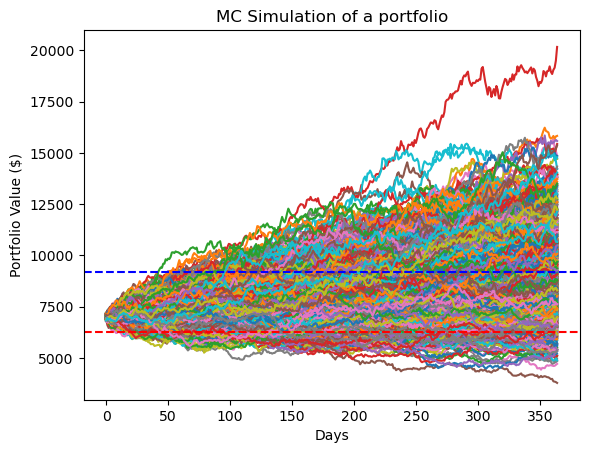

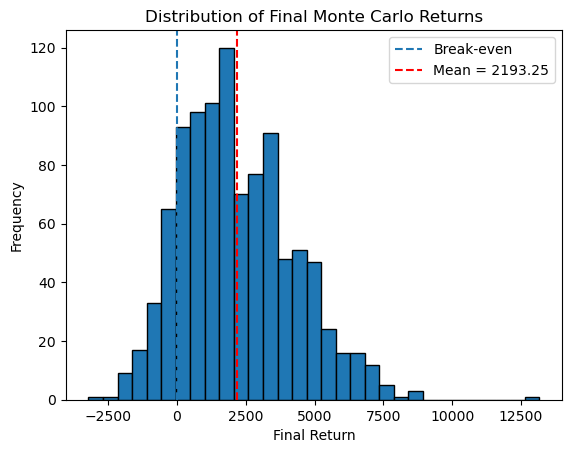

In [215]:
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.axhline(percentile_line, linestyle='--', color='r', label=f'{alpha}th percentile final value = {percentile_line:.2f}')
plt.axhline(mean_line, linestyle='--', color='b', label=f'{alpha}th percentile final value = {mean_line:.2f}')
plt.title('MC Simulation of a portfolio')
plt.show()

final_returns = (portResults - initialPortfolio)
mean_return = final_returns.mean()

plt.hist(final_returns, bins=int(math.sqrt(mc_sims)), edgecolor='black')
plt.axvline(0, linestyle='--', label='Break-even')
plt.axvline(mean_return, linestyle='--', label=f'Mean = {round(mean_return, 2)}', color='r')

plt.xlabel("Final Return")
plt.ylabel("Frequency")
plt.title("Distribution of Final Monte Carlo Returns")
plt.legend()
plt.show()